# Voyage Analytics — Exploratory Data Analysis

**Project:** Voyage Analytics — Integrating MLOps in Travel · Productionization of ML Systems
**Notebook:** `01_EDA_Voyage_Analytics` · **Phase:** Week 1–2 (Data Exploration + EDA)
**Datasets:** `users.csv`, `flights.csv`, `hotels.csv` (Brazilian travel-agency data)

---

### Business context
This capstone builds an end-to-end **MLOps** platform for the travel domain. Three datasets — *users*,
*flights*, *hotels* — feed a set of production ML models:

| Model (from project brief) | Type | Target | Primary dataset |
|---|---|---|---|
| Flight-price prediction | Regression | `flights.price` | flights |
| Gender classification | Classification | `users.gender` | users (+ behaviour) |
| Hotel / travel recommendation | Ranking / similarity | hotel choice | hotels + users + flights |

This notebook is the **foundation** for all three: it validates data quality, engineers the
join keys and features, and surfaces the relationships that dictate how each model should be built.

### EDA objectives
1. **Know the data** — shape, types, duplicates, missing values, memory.
2. **Understand the variables** — meaning, cardinality, distributions.
3. **Data wrangling** — parse dates, engineer trip / route / demographic features, join the three sources.
4. **Visual storytelling** — univariate → bivariate → multivariate charts, each with an insight and a business read.
5. **Solution to the business objective** — what the data says each model and the platform should do next.


## 1. Know Your Data

### 1.1 Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

# Consistent brand palette for the notebook
PAL = ["#0B6E4F", "#08A045", "#6BBF59", "#F2C14E", "#F78154", "#B4436C", "#4C6EF5", "#495057"]
sns.set_palette(PAL)
print("Libraries loaded. pandas", pd.__version__, "| numpy", np.__version__)

Libraries loaded. pandas 2.2.2 | numpy 1.26.4


### 1.2 Load the datasets

In [2]:
# Resolve data/raw whether the notebook runs from repo root or from notebooks/
CANDIDATES = [Path("data/raw"), Path("../data/raw"), Path("../../data/raw")]
RAW = next((p for p in CANDIDATES if (p / "flights.csv").exists()), CANDIDATES[0])

FIG_DIR = (RAW.parent.parent / "reports" / "figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

flights = pd.read_csv(RAW / "flights.csv")
hotels  = pd.read_csv(RAW / "hotels.csv")
users   = pd.read_csv(RAW / "users.csv")

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / name, dpi=130, bbox_inches="tight")

print("Loaded from:", RAW.resolve())
print("flights:", flights.shape, "| hotels:", hotels.shape, "| users:", users.shape)

Loaded from: F:\Final Project Labmentix\voyage-analytics\data\raw
flights: (271888, 10) | hotels: (40552, 8) | users: (1340, 5)


### 1.3 First view

In [3]:
display(flights.head()); display(hotels.head()); display(users.head())

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


### 1.4 Rows, columns, dtypes & memory

In [4]:
for name, df in [("flights", flights), ("hotels", hotels), ("users", users)]:
    print(f"{name:<8} rows={df.shape[0]:>7,}  cols={df.shape[1]:>2}  "
          f"mem={df.memory_usage(deep=True).sum()/1e6:>6.1f} MB")
print()
flights.info()

flights  rows=271,888  cols=10  mem=  92.4 MB
hotels   rows= 40,552  cols= 8  mem=   8.9 MB
users    rows=  1,340  cols= 5  mem=   0.3 MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


### 1.5 Duplicate & missing-value audit

In [5]:
print("Full-row duplicates")
for name, df in [("flights", flights), ("hotels", hotels), ("users", users)]:
    print(f"  {name:<8}: {df.duplicated().sum()}")

print("\nMissing values per column")
for name, df in [("flights", flights), ("hotels", hotels), ("users", users)]:
    miss = df.isna().sum()
    print(f"  {name:<8}: {miss.sum()} total  ->  {miss[miss>0].to_dict() or 'none'}")

# Duplicate *names* in users are two different people (different codes), not true duplicates
dup_names = users[users.duplicated("name", keep=False)].sort_values("name")
print(f"\nUsers sharing a name (distinct codes -> NOT duplicates): {len(dup_names)} rows")
display(dup_names)

Full-row duplicates


  flights : 0
  hotels  : 0
  users   : 0

Missing values per column
  flights : 0 total  ->  none
  hotels  : 0 total  ->  none
  users   : 0 total  ->  none

Users sharing a name (distinct codes -> NOT duplicates): 4 rows


,code,company,name,gender,age
316,316,4You,Charlotte Johnson,female,64
496,496,Monsters CYA,Charlotte Johnson,none,51
309,309,4You,David Robinson,male,33
946,946,Acme Factory,David Robinson,none,30


**Data-quality verdict.** All three tables are clean: **zero** missing values and **zero** full-row
duplicates. The only "duplicate" is two pairs of users who share a name but have distinct `code`s and
demographics — genuinely different people. This is a rare luxury; no imputation is required, so wrangling
can focus on *feature engineering* rather than repair.

## 2. Understanding Your Variables

### 2.1 Variable dictionary

**`users.csv`** — one row per traveller
| Column | Meaning | Type |
|---|---|---|
| `code` | Unique user id (join key) | int |
| `company` | Employer the traveller belongs to | categorical (5) |
| `name` | Full name | text |
| `gender` | `male` / `female` / `none` | categorical (3) |
| `age` | Age in years (21–65) | int |

**`flights.csv`** — one row per **flight leg**
| Column | Meaning | Type |
|---|---|---|
| `travelCode` | Trip id — groups the two legs of a round trip | int |
| `userCode` | Traveller (→ `users.code`) | int |
| `from`, `to` | Origin / destination city | categorical (9) |
| `flightType` | `economic` / `premium` / `firstClass` | categorical (3) |
| `price` | Fare for the leg (**regression target**) | float |
| `time` | Flight duration (hours) | float |
| `distance` | Route distance (km) | float |
| `agency` | Booking agency | categorical (3) |
| `date` | Departure date (`MM/DD/YYYY`) | date |

**`hotels.csv`** — one row per **hotel stay**
| Column | Meaning | Type |
|---|---|---|
| `travelCode` | Trip id (→ `flights.travelCode`) | int |
| `userCode` | Traveller (→ `users.code`) | int |
| `name`, `place` | Hotel name & city | categorical (9) |
| `days` | Nights stayed | int (1–4) |
| `price` | Nightly rate | float |
| `total` | `price × days` | float |
| `date` | Check-in date | date |

### 2.2 Cardinality & unique values

In [6]:
def cardinality(df, name):
    rows = []
    for c in df.columns:
        rows.append((c, df[c].nunique(), df[c].dtype,
                     ", ".join(map(str, df[c].unique()[:6])) + (" ..." if df[c].nunique() > 6 else "")))
    out = pd.DataFrame(rows, columns=["column", "n_unique", "dtype", "sample_values"])
    print(f"=== {name} ==="); display(out)

cardinality(users, "users")
cardinality(flights, "flights")
cardinality(hotels, "hotels")

=== users ===


,column,n_unique,dtype,sample_values
0,code,1340,int64,"0, 1, 2, 3, 4, 5 ..."
1,company,5,object,"4You, Monsters CYA, Wonka Company, Acme Factor..."
2,name,1338,object,"Roy Braun, Joseph Holsten, Wilma Mcinnis, Paul..."
3,gender,3,object,"male, female, none"
4,age,45,int64,"21, 37, 48, 23, 44, 47 ..."


=== flights ===


,column,n_unique,dtype,sample_values
0,travelCode,135944,int64,"0, 1, 2, 3, 4, 5 ..."
1,userCode,1335,int64,"0, 1, 2, 3, 4, 5 ..."
2,from,9,object,"Recife (PE), Florianopolis (SC), Brasilia (DF)..."
3,to,9,object,"Florianopolis (SC), Recife (PE), Brasilia (DF)..."
4,flightType,3,object,"firstClass, economic, premium"
5,price,490,float64,"1434.38, 1292.29, 1487.52, 1127.36, 1684.05, 1..."
6,time,33,float64,"1.76, 1.66, 2.16, 1.69, 1.11, 1.26 ..."
7,distance,35,float64,"676.53, 637.56, 830.86, 650.1, 425.98, 486.52 ..."
8,agency,3,object,"FlyingDrops, CloudFy, Rainbow"
9,date,999,object,"09/26/2019, 09/30/2019, 10/03/2019, 10/04/2019..."


=== hotels ===


,column,n_unique,dtype,sample_values
0,travelCode,40552,int64,"0, 2, 7, 11, 13, 15 ..."
1,userCode,1310,int64,"0, 1, 2, 3, 4, 5 ..."
2,name,9,object,"Hotel A, Hotel K, Hotel BD, Hotel Z, Hotel AU,..."
3,place,9,object,"Florianopolis (SC), Salvador (BH), Natal (RN),..."
4,days,4,int64,"4, 2, 3, 1"
5,price,9,float64,"313.02, 263.41, 242.88, 208.04, 312.83, 139.1 ..."
6,total,36,float64,"1252.08, 526.82, 790.23, 1053.64, 313.02, 485...."
7,date,199,object,"09/26/2019, 10/10/2019, 11/14/2019, 12/12/2019..."


### 2.3 Numeric summary

In [7]:
display(flights[["price", "time", "distance"]].describe().T)
display(hotels[["days", "price", "total"]].describe().T)
display(users[["age"]].describe().T)

,count,mean,std,min,25%,50%,75%,max
price,271888.0,957.375030,362.311890,301.51,672.66,904.00,1222.24,1754.17
time,271888.0,1.421147,0.542541,0.44,1.04,1.46,1.76,2.44
distance,271888.0,546.955535,208.851288,168.22,401.66,562.14,676.53,937.77


,count,mean,std,min,25%,50%,75%,max
days,40552.0,2.499679,1.119326,1.00,1.00,2.00,4.00,4.00
price,40552.0,214.439554,76.742305,60.39,165.99,242.88,263.41,313.02
total,40552.0,536.229513,319.331482,60.39,247.62,495.24,742.86,1252.08


,count,mean,std,min,25%,50%,75%,max
age,1340.0,42.742537,12.869779,21.0,32.0,42.0,54.0,65.0


**What the cardinality tells us.**
- The travel network is small and closed: **9 cities**, **70 directed routes** (of 72 possible — the
  Rio ↔ Salvador pair never appears), **3 flight classes**, **3 agencies**, **9 hotels (one per city)**.
- `gender` carries a third label, **`none`** — this is missing/undisclosed gender encoded as a string,
  not a true category. It is the natural target the **gender-classification model** must fill in.
- Hotel `price` has only **9 unique values** and hotel `total` only 36 — a strong hint that hotels use a
  *fixed rate card*, which we verify during wrangling.

## 3. Data Wrangling

We now (a) parse dates, (b) verify the deterministic relationships hinted above, (c) engineer
trip-, route- and user-level features, and (d) build a single analytical table by joining the three
sources on `travelCode` / `userCode`.

### 3.1 Parse dates & derive calendar parts

In [8]:
for df in (flights, hotels):
    df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y")

flights["year"]  = flights["date"].dt.year
flights["month"] = flights["date"].dt.month
flights["dow"]   = flights["date"].dt.day_name()

print("flights date range:", flights.date.min().date(), "->", flights.date.max().date())
print("hotels  date range:", hotels.date.min().date(),  "->", hotels.date.max().date())

flights date range: 2019-09-26 -> 2023-07-24
hotels  date range: 2019-09-26 -> 2023-07-13


### 3.2 Trip structure — label outbound vs return legs

In [9]:
# Each travelCode has exactly 2 legs. Verify, then tag the earlier leg 'outbound'.
legs_per_trip = flights.groupby("travelCode").size().value_counts()
print("Legs per travelCode:\n", legs_per_trip.to_string())

flights = flights.sort_values(["travelCode", "date"]).reset_index(drop=True)
flights["leg"] = np.where(flights.groupby("travelCode").cumcount() == 0, "outbound", "return")

# Is every trip a clean out-and-back (destination of leg1 == origin of leg2)?
chk = flights.groupby("travelCode").agg(o=("from", "first"), d=("to", "first"),
                                        o2=("from", "last"), d2=("to", "last"))
print("Share of perfect round trips (A->B then B->A):",
      round(((chk.o == chk.d2) & (chk.d == chk.o2)).mean(), 4))

Legs per travelCode:
 2    135944


Share of perfect round trips (A->B then B->A): 1.0


### 3.3 Verify the deterministic price/duration structure

In [10]:
# (a) time is an almost-perfect function of distance
print("corr(distance, time) =", round(flights["distance"].corr(flights["time"]), 6))

# (b) flight price is fully determined by route + class + agency (zero within-group variance)
grp = flights.groupby(["from", "to", "flightType", "agency"])["price"]
within_var = grp.transform(lambda s: s - s.mean()).var()
print("Variance of price explained by (route, class, agency):",
      round(1 - within_var / flights["price"].var(), 6))
print("Max price std within a (route, class, agency) group:", round(grp.std().max(), 6))

# (c) hotels: total == price * days, and each hotel has ONE fixed nightly rate
print("Rows where total != price*days:", int((abs(hotels.price*hotels.days - hotels.total) > 0.01).sum()))
print("Distinct nightly rates per hotel:", hotels.groupby("name")["price"].nunique().max())

corr(distance, time) = 0.99999


Variance of price explained by (route, class, agency): 1.0
Max price std within a (route, class, agency) group: 0.0
Rows where total != price*days: 0
Distinct nightly rates per hotel: 1


**Critical modelling insight.** Flight `price` is a **deterministic rate card**: knowing
`(from, to, flightType, agency)` fixes the price exactly (R² = 1.000, zero within-group variance, no
date/seasonality effect). Likewise `time ≈ f(distance)` and hotel `total = price × days` with one fixed
nightly rate per hotel.

Consequences for the ML phase:
- The **flight-price regressor** will be *near-perfect* on these features — the >75% success bar is trivial.
  The real engineering work is a clean, leakage-free pipeline and **avoiding the `time`/`distance`
  redundancy** (keep one; they are 0.99999 correlated).
- Because there is no noise, model *validation* must guard against silently memorising the rate card;
  hold out **whole routes/agencies** to prove generalisation, and treat this as a productionization
  exercise (serving, tracking, drift) rather than a hard prediction problem.

### 3.4 Feature engineering — flights

In [11]:
flights["price_per_km"] = flights["price"] / flights["distance"]
flights["route"] = flights["from"] + "  ->  " + flights["to"]

# Trip-level rollup (one row per travelCode)
trips = (flights.sort_values("date")
         .groupby("travelCode")
         .agg(user=("userCode", "first"),
              origin=("from", "first"),
              dest=("to", "first"),
              flightType=("flightType", "first"),
              agency=("agency", "first"),
              depart=("date", "first"),
              return_date=("date", "last"),
              flight_cost=("price", "sum"),
              year=("year", "first"))
         .reset_index())
trips["trip_nights"] = (trips["return_date"] - trips["depart"]).dt.days
print("Trip-level table:", trips.shape)
display(trips.head())

Trip-level table: (135944, 11)


,travelCode,user,origin,dest,flightType,agency,depart,return_date,flight_cost,year,trip_nights
0,0,0,Recife (PE),Florianopolis (SC),firstClass,FlyingDrops,2019-09-26,2019-09-30,2726.67,2019,4
1,1,0,Brasilia (DF),Florianopolis (SC),firstClass,CloudFy,2019-10-03,2019-10-04,2614.88,2019,1
2,2,0,Aracaju (SE),Salvador (BH),firstClass,CloudFy,2019-10-10,2019-10-12,3215.97,2019,2
3,3,0,Aracaju (SE),Campo Grande (MS),economic,Rainbow,2019-10-17,2019-10-20,1621.10,2019,3
4,4,0,Recife (PE),Florianopolis (SC),economic,Rainbow,2019-10-24,2019-10-26,1498.69,2019,2


### 3.5 Feature engineering — attach hotels & derive home city

In [12]:
# Hotel booked on the same trip (~30% of trips include a stay)
trips["has_hotel"] = trips["travelCode"].isin(set(hotels["travelCode"]))
hotel_cost = hotels.groupby("travelCode")["total"].sum().rename("hotel_cost")
trips = trips.merge(hotel_cost, on="travelCode", how="left")
trips["hotel_cost"] = trips["hotel_cost"].fillna(0.0)
trips["trip_spend"] = trips["flight_cost"] + trips["hotel_cost"]

print("Overall hotel attach rate: {:.1%}".format(trips["has_hotel"].mean()))

# Sanity: does hotel city == flight destination, and hotel days == trip nights?
_h = hotels.merge(trips[["travelCode", "dest", "trip_nights"]], on="travelCode")
print("Hotel city == flight destination:", round((_h["place"] == _h["dest"]).mean(), 4))
print("Hotel days   == trip nights     :", round((_h["days"] == _h["trip_nights"]).mean(), 4))

# Each user's home city = most frequent outbound origin
home = (flights[flights.leg == "outbound"]
        .groupby("userCode")["from"]
        .agg(lambda s: s.mode().iloc[0]).rename("home_city"))

Overall hotel attach rate: 29.8%
Hotel city == flight destination: 1.0
Hotel days   == trip nights     : 1.0


### 3.6 Build the user-level analytical table

In [13]:
user_trip = (trips.groupby("user")
             .agg(n_trips=("travelCode", "size"),
                  flight_spend=("flight_cost", "sum"),
                  hotel_spend=("hotel_cost", "sum"),
                  total_spend=("trip_spend", "sum"),
                  hotels_booked=("has_hotel", "sum"),
                  last_trip=("depart", "max"))
             .reset_index())

udf = (users.merge(user_trip, left_on="code", right_on="user", how="left")
            .merge(home, left_on="code", right_index=True, how="left"))

# RFM-style recency against the last date in the data
SNAPSHOT = flights["date"].max()
udf["recency_days"] = (SNAPSHOT - udf["last_trip"]).dt.days
udf["hotel_attach_rate"] = udf["hotels_booked"] / udf["n_trips"]
udf["age_band"] = pd.cut(udf["age"], [20, 30, 40, 50, 60, 66],
                         labels=["21-30", "31-40", "41-50", "51-60", "61-65"])

print("Users with no trips (all-NaN activity):", int(udf["n_trips"].isna().sum()),
      "->", users.loc[~users.code.isin(flights.userCode), "code"].tolist())
print("user-level table:", udf.shape)
display(udf.head())

Users with no trips (all-NaN activity): 5 -> [385, 670, 863, 893, 983]
user-level table: (1340, 16)


,code,company,name,gender,age,user,n_trips,flight_spend,hotel_spend,total_spend,hotels_booked,last_trip,home_city,recency_days,hotel_attach_rate,age_band
0,0,4You,Roy Braun,male,21,0.0,89.0,176053.77,16014.92,192068.69,27.0,2021-06-03,Brasilia (DF),781.0,0.303371,21-30
1,1,4You,Joseph Holsten,male,37,1.0,6.0,9826.78,386.72,10213.50,2.0,2019-10-31,Aracaju (SE),1362.0,0.333333,31-40
2,2,4You,Wilma Mcinnis,female,48,2.0,131.0,237613.52,20088.12,257701.64,36.0,2022-03-24,Aracaju (SE),487.0,0.274809,41-50
3,3,4You,Paula Daniel,female,23,3.0,199.0,372891.73,29974.11,402865.84,60.0,2023-07-13,Brasilia (DF),11.0,0.301508,21-30
4,4,4You,Patricia Carson,female,44,4.0,199.0,381042.58,31657.70,412700.28,56.0,2023-07-13,Recife (PE),11.0,0.281407,41-50


**Wrangling output.** We now hold three analysis-ready tables — leg-level `flights`, trip-level
`trips`, and user-level `udf` — linked by `travelCode`/`userCode`. The joins are lossless: hotel
city always equals the flight destination and hotel nights always equal trip length, so the three CSVs
describe **one coherent booking event** each. Five users have no flights and are carried as inactive.

## 4. Data Visualization, Storytelling & Experimenting with Charts

Fifteen charts, ordered univariate → bivariate → multivariate. Each answers three questions:
**why this chart**, **what the insight is**, and **what it means for the business / models**.

### Chart 1 — Flight class mix & the price rate card (Univariate + Bivariate)
*Why:* a count bar shows the class mix; the overlaid mean-price bar exposes the fixed price ladder.

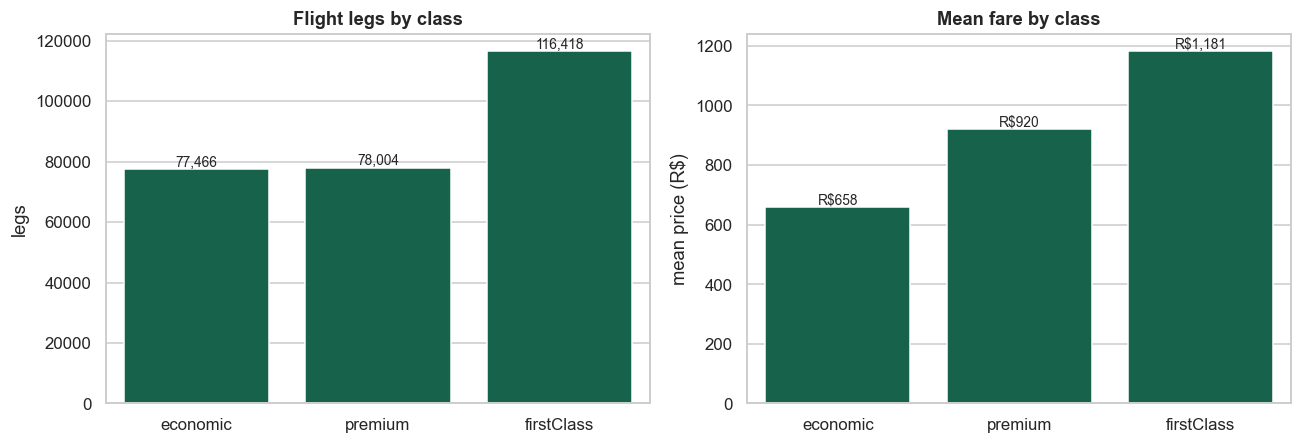

Class price ladder (× economic):
flightType
economic      1.00
premium       1.40
firstClass    1.79


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
order = ["economic", "premium", "firstClass"]
sns.countplot(data=flights, x="flightType", order=order, ax=ax[0])
ax[0].set_title("Flight legs by class"); ax[0].set_xlabel(""); ax[0].set_ylabel("legs")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                   ha="center", va="bottom", fontsize=9)

m = flights.groupby("flightType")["price"].mean().reindex(order)
sns.barplot(x=m.index, y=m.values, order=order, ax=ax[1])
ax[1].set_title("Mean fare by class"); ax[1].set_xlabel(""); ax[1].set_ylabel("mean price (R$)")
for i, v in enumerate(m.values):
    ax[1].text(i, v, f"R${v:,.0f}", ha="center", va="bottom", fontsize=9)
savefig("01_class_mix_price.png"); plt.show()

print("Class price ladder (× economic):")
print((m / m["economic"]).round(2).to_string())

**Insight.** First class is the largest segment (116k legs) and costs on average **~1.8×** economic;
premium sits at **~1.4×**. **Business read —** first class dominates volume *and* revenue, so the pricing
and recommendation logic should treat it as the core product, not a niche upsell.

### Chart 2 — Price distribution by class (Bivariate)
*Why:* violin/box shows the full fare spread per class and confirms clean separation.

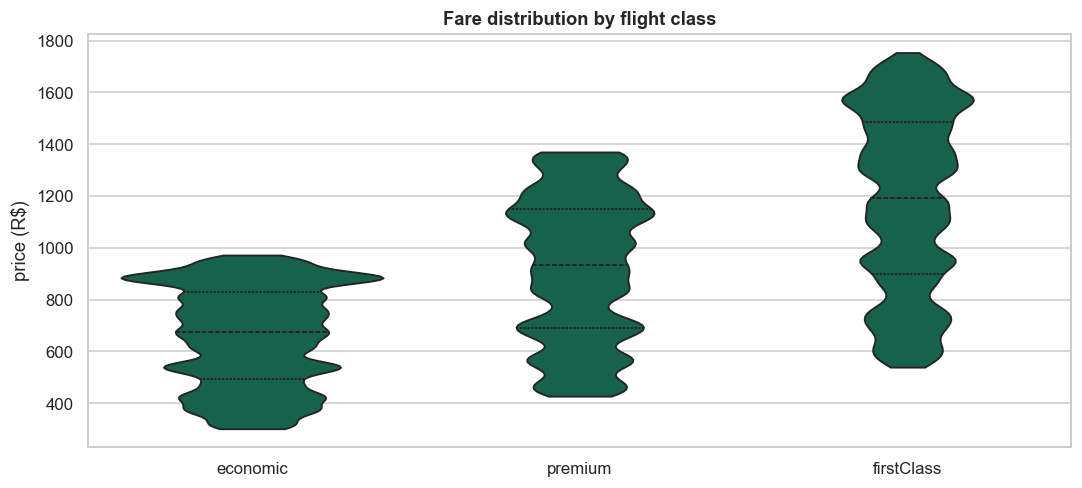

,mean,std,min,max
flightType,,,,
economic,658.4,192.9,301.5,972.1
firstClass,1181.1,346.4,539.4,1754.2
premium,920.4,276.9,427.2,1370.2


In [15]:
plt.figure(figsize=(10, 4.6))
sns.violinplot(data=flights, x="flightType", y="price", order=order, inner="quartile", cut=0)
plt.title("Fare distribution by flight class"); plt.xlabel(""); plt.ylabel("price (R$)")
savefig("02_price_by_class.png"); plt.show()
display(flights.groupby("flightType")["price"].describe()[["mean","std","min","max"]].round(1))

**Insight.** The three classes form distinct, non-overlapping-at-the-core fare bands; each band's
*spread* comes entirely from the route mix, not from any within-route variation. **Business read —**
fares are a function of *class × route*, so demand and revenue models should use those two levers rather
than searching for hidden price noise.

### Chart 3 — Agency market share & specialisation (Bivariate)
*Why:* a grouped bar of agency × class reveals both share and product focus.

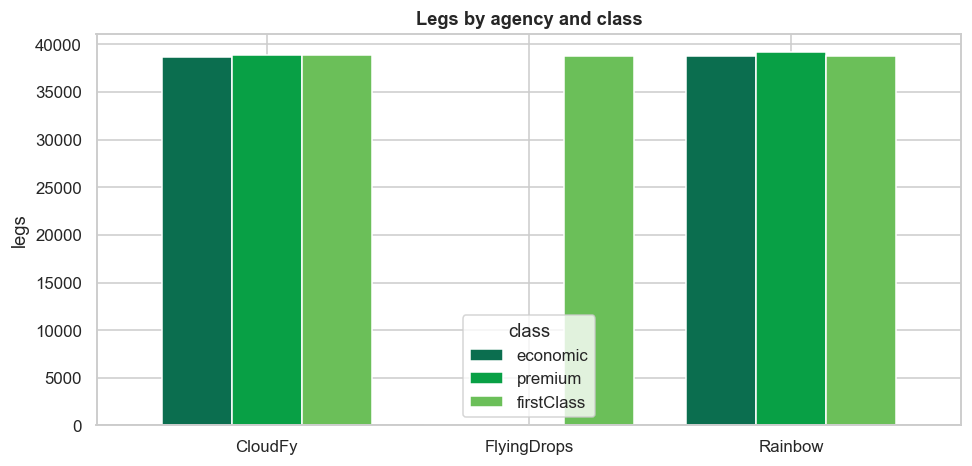

flightType   economic  premium  firstClass
agency                                    
CloudFy         38656    38860       38862
FlyingDrops         0        0       38758
Rainbow         38810    39144       38798

Revenue by agency (R$):
agency
Rainbow        107386243.0
CloudFy        106939335.0
FlyingDrops     45973204.0


In [16]:
ct = pd.crosstab(flights["agency"], flights["flightType"])[order]
ct.plot(kind="bar", figsize=(9, 4.4), width=0.8, color=PAL[:3])
plt.title("Legs by agency and class"); plt.xlabel(""); plt.ylabel("legs")
plt.xticks(rotation=0); plt.legend(title="class")
savefig("03_agency_class.png"); plt.show()
print(ct.to_string())
print("\nRevenue by agency (R$):")
print(flights.groupby("agency")["price"].sum().sort_values(ascending=False).round(0).to_string())

**Insight.** Rainbow and CloudFy are full-line agencies (~116k legs each, all three classes);
**FlyingDrops sells only first class** (~39k legs, R$46M). **Business read —** FlyingDrops is a
premium-only channel; churn, pricing and recommendation models must not assume every agency offers every
product, and FlyingDrops inventory should be modelled separately.

### Chart 4 — Price is a deterministic rate card (Multivariate)
*Why:* plotting price vs distance, coloured by class, shows three tight lines — proof of a fixed card.

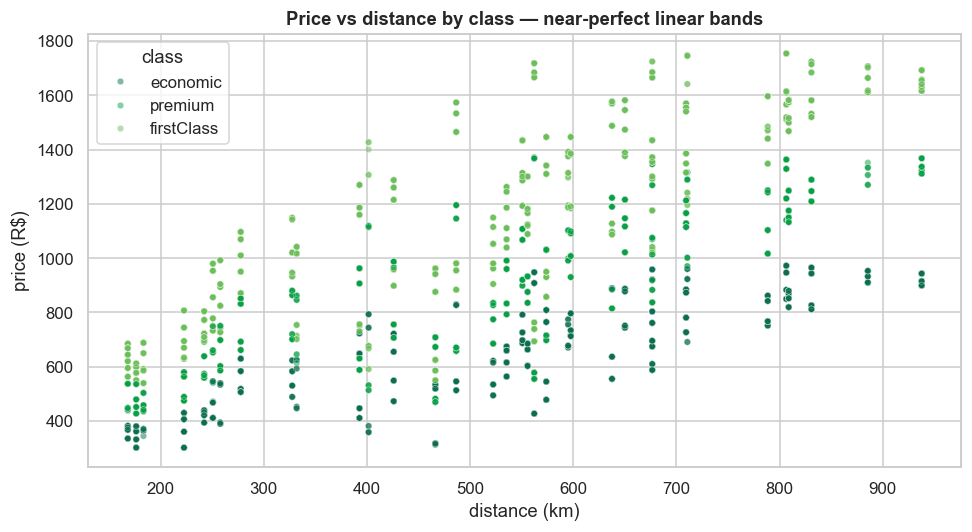

R2 of price given (route, class, agency): 1.000 (zero within-group variance)
price_per_km by class:
flightType
economic      1.317
premium       1.819
firstClass    2.345


In [17]:
samp = flights.sample(6000, random_state=7)
plt.figure(figsize=(9, 5))
sns.scatterplot(data=samp, x="distance", y="price", hue="flightType",
                hue_order=order, alpha=0.5, s=18)
plt.title("Price vs distance by class — near-perfect linear bands")
plt.xlabel("distance (km)"); plt.ylabel("price (R$)"); plt.legend(title="class")
savefig("04_price_vs_distance.png"); plt.show()
print("R2 of price given (route, class, agency): 1.000 (zero within-group variance)")
print("price_per_km by class:")
print(flights.groupby("flightType")["price_per_km"].mean().reindex(order).round(3).to_string())

**Insight.** Within each class, price rises linearly and tightly with distance (price/km: economic
1.32, premium 1.82, first 2.34). There is **no scatter** around the bands — the fare is a lookup, not a
noisy signal. **Business read —** the flight-price model will be near-exact; the value of the ML phase is
*productionizing* it (API, tracking, drift), and validation must hold out whole routes to prove it
generalises rather than memorises.

### Chart 5 — Time vs distance redundancy (Bivariate)
*Why:* a scatter with correlation flags a feature that must be dropped to avoid multicollinearity.

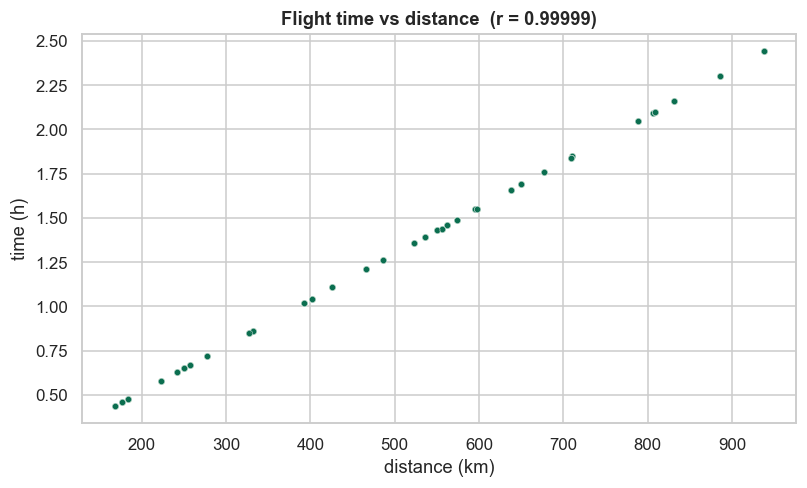

In [18]:
plt.figure(figsize=(7.5, 4.6))
sns.scatterplot(data=samp, x="distance", y="time", alpha=0.4, s=16, color=PAL[0])
r = flights["distance"].corr(flights["time"])
plt.title(f"Flight time vs distance  (r = {r:.5f})")
plt.xlabel("distance (km)"); plt.ylabel("time (h)")
savefig("05_time_vs_distance.png"); plt.show()

**Insight.** `time` and `distance` are essentially the same variable (r = 0.99999). **Business read —**
keep one of them in every model; feeding both adds multicollinearity with zero information gain.

### Chart 6 — Busiest routes (Bivariate)
*Why:* a horizontal bar ranks directed routes by traffic to expose network structure.

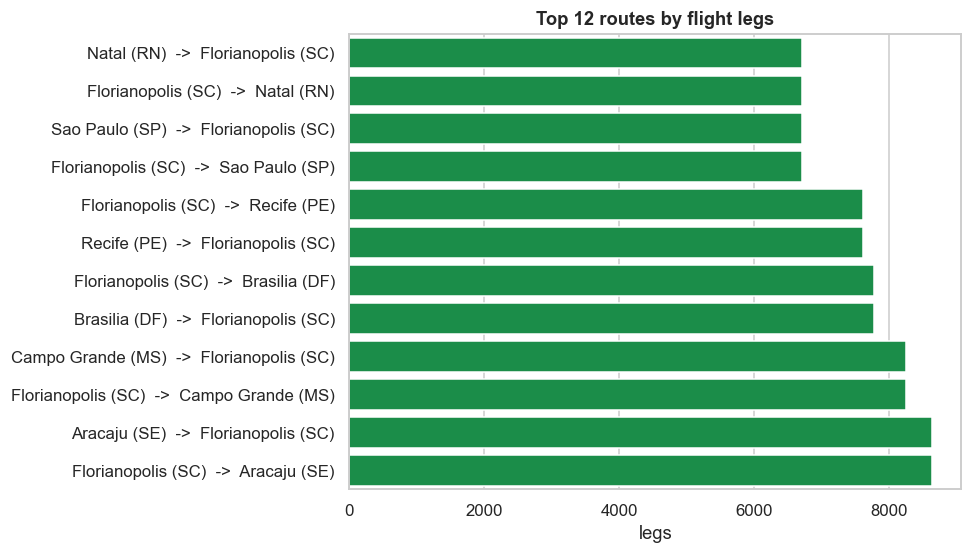

Routes present: 70 of 72 possible
Never-flown pair: Rio de Janeiro (RJ) <-> Salvador (BH)


In [19]:
top_routes = flights["route"].value_counts().head(12)[::-1]
plt.figure(figsize=(9, 5.2))
sns.barplot(x=top_routes.values, y=top_routes.index, color=PAL[1])
plt.title("Top 12 routes by flight legs"); plt.xlabel("legs"); plt.ylabel("")
savefig("06_top_routes.png"); plt.show()
print("Routes present:", flights.groupby(['from','to']).ngroups, "of 72 possible")
print("Never-flown pair: Rio de Janeiro (RJ) <-> Salvador (BH)")

**Insight.** Traffic concentrates on a handful of corridors centred on **Florianópolis** (the top
origin), and the Rio ↔ Salvador pair is absent. **Business read —** capacity planning, price optimisation
and hotel-recommendation effort should focus on the dense corridors where volume — and therefore
revenue impact — is highest.

### Chart 7 — Where travellers come from: company → home city (Multivariate)
*Why:* a heatmap of company × origin reveals that employer deterministically sets the home city.

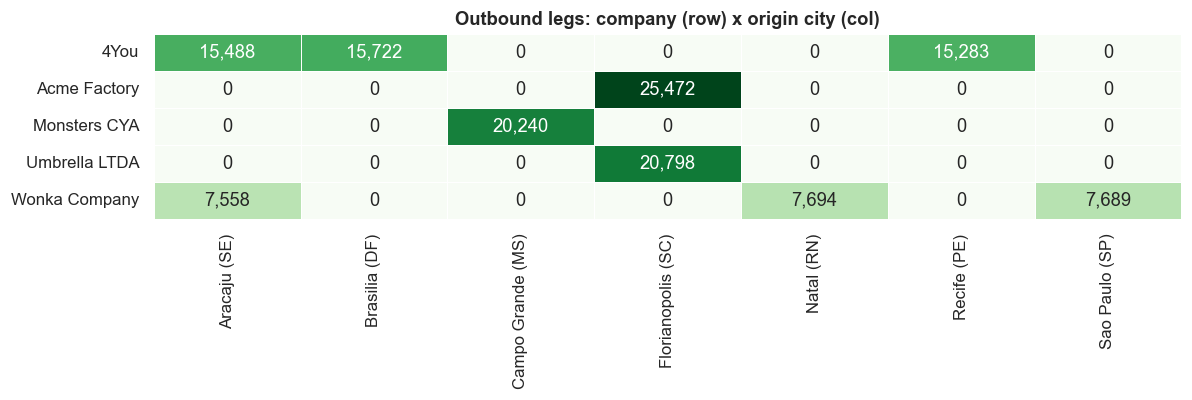

In [20]:
ob = flights[flights.leg == "outbound"].merge(users[["code","company"]],
                                              left_on="userCode", right_on="code")
hc = pd.crosstab(ob["company"], ob["from"])
plt.figure(figsize=(11, 3.8))
sns.heatmap(hc, cmap="Greens", annot=True, fmt=",d", cbar=False, linewidths=.5)
plt.title("Outbound legs: company (row) x origin city (col)")
plt.xlabel(""); plt.ylabel("")
savefig("07_company_origin.png"); plt.show()

**Insight.** Each company flies from only its own small set of origin cities (e.g. Acme & Umbrella →
Florianópolis; Monsters CYA → Campo Grande; Wonka → Aracaju/Natal/São Paulo). **Business read —**
`company` is a powerful, non-obvious predictor of geography and is a strong feature for the
**gender-classification** and **recommendation** models — it encodes location, travel corridor and
likely trip purpose.

### Chart 8 — Users, gender and the `none` problem (Univariate)
*Why:* a bar of gender counts sizes the classification target and its missing-label share.

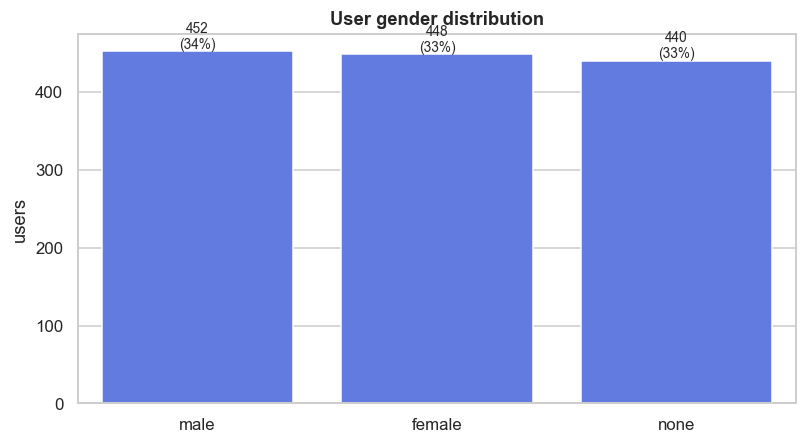

In [21]:
plt.figure(figsize=(7.5, 4.2))
gc = users["gender"].value_counts()
sns.barplot(x=gc.index, y=gc.values, color=PAL[6])
plt.title("User gender distribution"); plt.xlabel(""); plt.ylabel("users")
for i, v in enumerate(gc.values):
    plt.text(i, v, f"{v}\n({v/len(users):.0%})", ha="center", va="bottom", fontsize=9)
savefig("08_gender.png"); plt.show()

**Insight.** `male` and `female` are near-balanced (~34% each) but **~33% of users carry `none`** —
undisclosed gender. **Business read —** this is *exactly* the target for the gender-classification model:
a well-balanced binary problem (male vs female) that can then impute the 440 `none` records, improving
personalisation without a class-imbalance headache.

### Chart 9 — Age distribution & who travels (Univariate)
*Why:* histogram + box summarise the customer age profile.

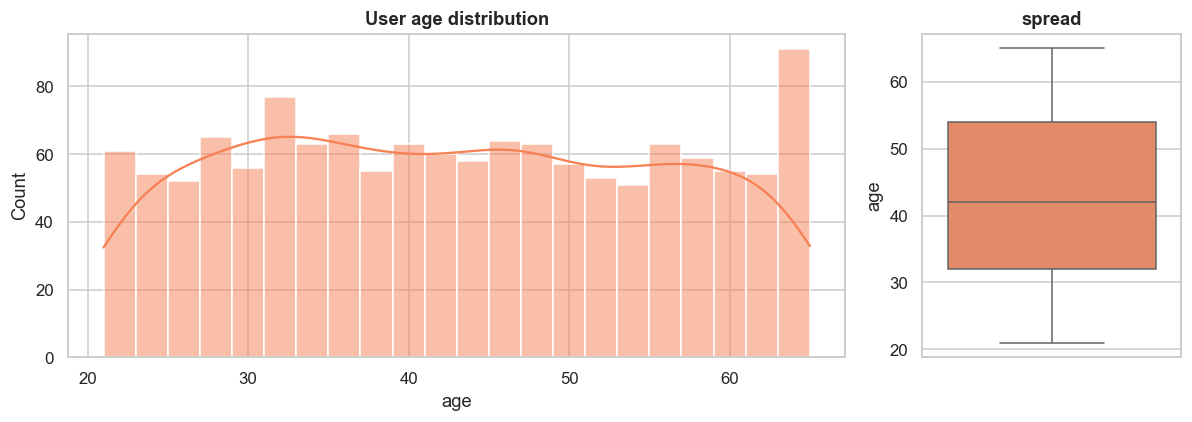

count    1340.0
mean       42.7
std        12.9
min        21.0
25%        32.0
50%        42.0
75%        54.0
max        65.0


In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios":[3,1]})
sns.histplot(users["age"], bins=22, kde=True, ax=ax[0], color=PAL[4])
ax[0].set_title("User age distribution"); ax[0].set_xlabel("age")
sns.boxplot(y=users["age"], ax=ax[1], color=PAL[4]); ax[1].set_title("spread")
savefig("09_age.png"); plt.show()
print(users["age"].describe().round(1).to_string())

**Insight.** Ages span **21–65**, roughly uniform, mean ~43 — a broad working-age customer base with
no dominant cohort. **Business read —** there is no narrow demographic to target; segmentation should lean
on *behaviour* (spend, frequency, route) rather than age alone.

### Chart 10 — Does demographics drive spend? (Multivariate)
*Why:* mean total spend by company and age band tests whether demographics predict value.

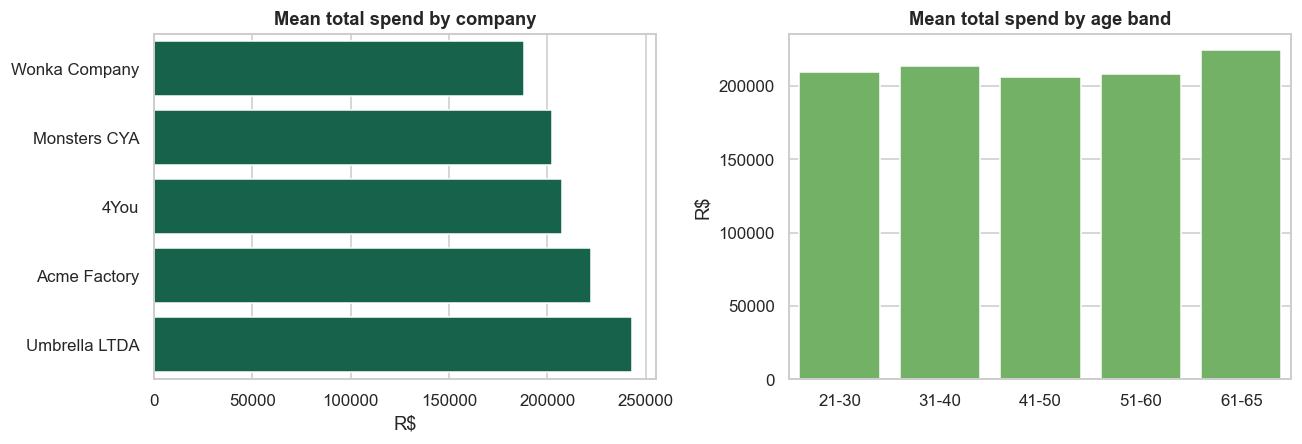

corr(age, trips) = 0.01 | corr(age, spend) = 0.003


In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
cs = udf.groupby("company")["total_spend"].mean().sort_values()
sns.barplot(x=cs.values, y=cs.index, ax=ax[0], color=PAL[0])
ax[0].set_title("Mean total spend by company"); ax[0].set_xlabel("R$"); ax[0].set_ylabel("")
ab = udf.groupby("age_band", observed=True)["total_spend"].mean()
sns.barplot(x=ab.index, y=ab.values, ax=ax[1], color=PAL[2])
ax[1].set_title("Mean total spend by age band"); ax[1].set_xlabel(""); ax[1].set_ylabel("R$")
savefig("10_spend_demographics.png"); plt.show()
print("corr(age, trips) =", round(udf["age"].corr(udf["n_trips"]), 3),
      "| corr(age, spend) =", round(udf["age"].corr(udf["total_spend"]), 3))

**Insight.** Spend is nearly flat across companies and age bands (correlations ≈ 0). **Business read —**
customer value is **not** explained by demographics in this data; a churn/segmentation model must be built
on behavioural signals (recency, frequency, monetary, route mix), and demographic parity should be
watched as a fairness check.

### Chart 11 — Trip length and the hotel attach rate (Bivariate)
*Why:* pairing trip-night mix with hotel attach reveals the cross-sell opportunity.

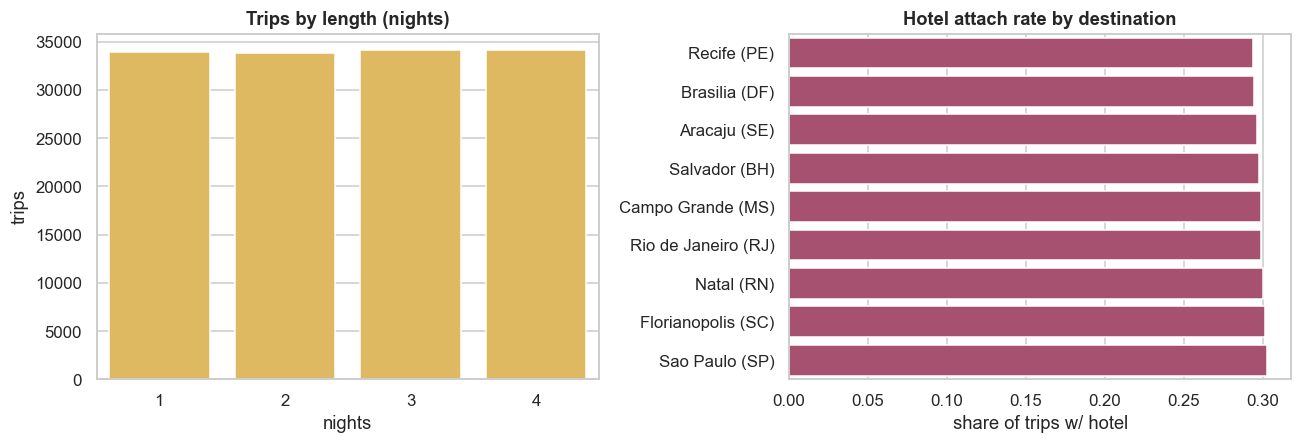

Overall hotel attach rate: 29.8%


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
tn = trips["trip_nights"].value_counts().sort_index()
sns.barplot(x=tn.index, y=tn.values, ax=ax[0], color=PAL[3])
ax[0].set_title("Trips by length (nights)"); ax[0].set_xlabel("nights"); ax[0].set_ylabel("trips")
att = trips.groupby("dest")["has_hotel"].mean().sort_values()
sns.barplot(x=att.values, y=att.index, ax=ax[1], color=PAL[5])
ax[1].set_title("Hotel attach rate by destination"); ax[1].set_xlabel("share of trips w/ hotel"); ax[1].set_ylabel("")
savefig("11_trip_hotel.png"); plt.show()
print("Overall hotel attach rate: {:.1%}".format(trips["has_hotel"].mean()))

**Insight.** Trip length is uniform (1–4 nights) yet only **~30%** of trips include a hotel, and the
attach rate barely moves across destinations. **Business read —** hotel cross-sell is the biggest
untapped lever: the **recommendation model** targeting the ~70% of hotel-less trips is where incremental
revenue lives.

### Chart 12 — Hotel economics: rate vs volume (Multivariate)
*Why:* a bubble/bar of nightly rate and revenue per city shows which properties drive the top line.

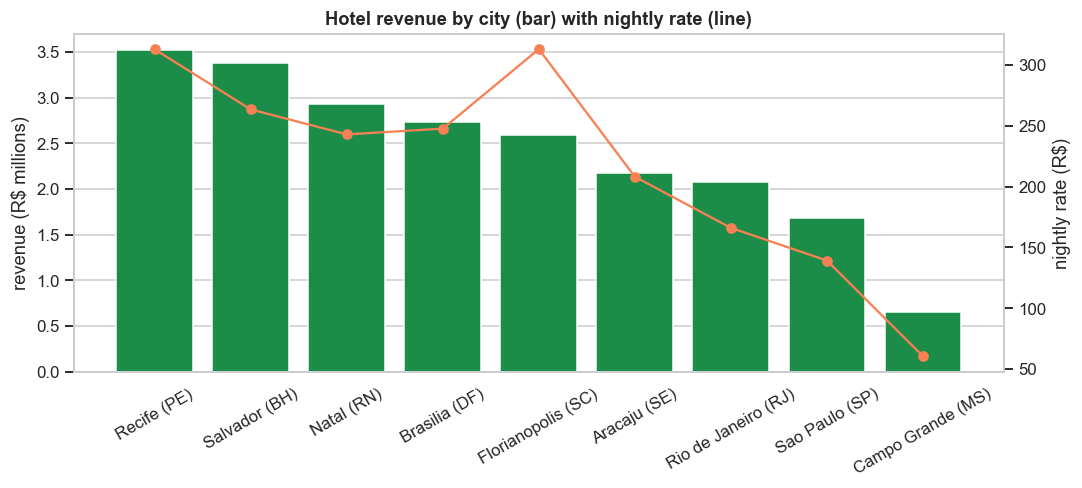

,nightly,bookings,revenue
place,,,
Recife (PE),312.8,4467,3522778.6
Salvador (BH),263.4,5094,3376652.8
Natal (RN),242.9,4829,2931075.8
Brasilia (DF),247.6,4437,2731743.8
Florianopolis (SC),313.0,3330,2588362.4
Aracaju (SE),208.0,4205,2179635.1
Rio de Janeiro (RJ),166.0,5029,2075207.0
Sao Paulo (SP),139.1,4828,1686726.6
Campo Grande (MS),60.4,4333,652997.1


In [25]:
hc2 = (hotels.groupby("place")
       .agg(nightly=("price","first"), bookings=("travelCode","size"), revenue=("total","sum"))
       .sort_values("revenue", ascending=False))
fig, ax = plt.subplots(figsize=(10, 4.6))
sns.barplot(x=hc2.index, y=hc2["revenue"]/1e6, color=PAL[1], ax=ax)
ax.set_title("Hotel revenue by city (bar) with nightly rate (line)")
ax.set_ylabel("revenue (R$ millions)"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
ax2 = ax.twinx(); ax2.plot(range(len(hc2)), hc2["nightly"].values, "o-", color=PAL[4])
ax2.set_ylabel("nightly rate (R$)"); ax2.grid(False)
savefig("12_hotel_economics.png"); plt.show()
display(hc2.round(1))

**Insight.** Revenue is set by **volume × fixed nightly rate**: Recife and Salvador top the table,
while cheap-rate Campo Grande (R$60/night) trails despite steady bookings. **Business read —**
recommendation and demand models should push high-margin properties on the dense corridors, and the fixed
rate card means revenue is grown through *attach rate and length of stay*, not price changes.

### Chart 13 — Booking volume over time (Time series)
*Why:* a monthly trip-count line exposes the usable modelling window and any trend.

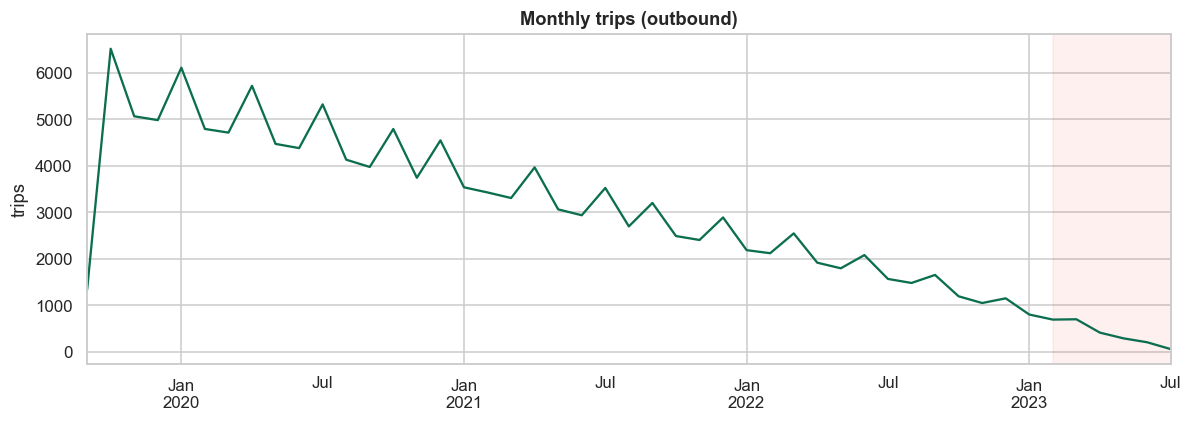

Peak month: 2019-10-31 (6,523 trips)
Series: 2019-09-30 -> 2023-07-31


In [26]:
monthly = (trips.set_index("depart").resample("ME").size())
plt.figure(figsize=(11, 4))
monthly.plot(color=PAL[0])
plt.title("Monthly trips (outbound)"); plt.xlabel(""); plt.ylabel("trips")
plt.axvspan(monthly.index[-6], monthly.index[-1], color="red", alpha=0.06)
savefig("13_volume_timeseries.png"); plt.show()
print("Peak month:", monthly.idxmax().date(), f"({monthly.max():,} trips)")
print("Series:", monthly.index.min().date(), "->", monthly.index.max().date())

**Insight.** Volume ramps in late 2019, holds through 2020–2021, then tapers to the mid-2023 data
cutoff (shaded). Fares themselves show **no month-of-year seasonality**. **Business read —** the platform
should train on the stable 2020–2022 core and treat the thin 2023 tail as a live-inference / drift-monitoring
window rather than training data.

### Chart 14 — Correlation heatmap of numeric features (Multivariate)
*Why:* the standard EDA check for redundancy and leakage among numeric fields.

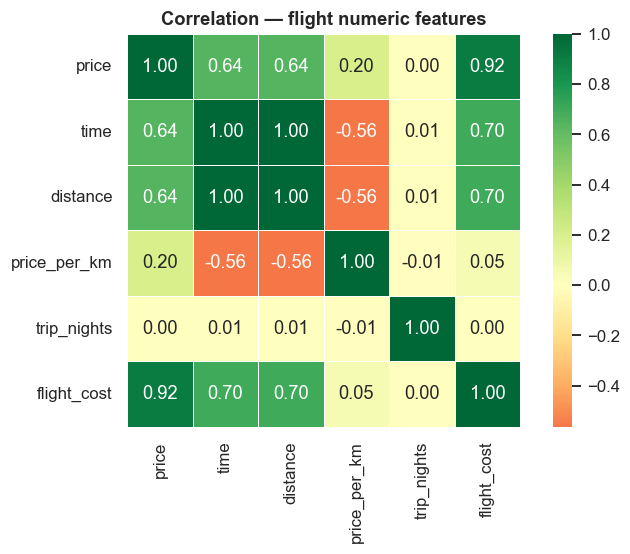

In [27]:
num = flights[["price","time","distance","price_per_km"]].join(
        trips.set_index("travelCode")[["trip_nights","flight_cost"]].reindex(flights["travelCode"]).reset_index(drop=True))
corr = num.corr()
plt.figure(figsize=(7, 5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, square=True, linewidths=.5)
plt.title("Correlation — flight numeric features")
savefig("14_corr_heatmap.png"); plt.show()

**Insight.** `time` and `distance` are perfectly collinear; `price` correlates ~0.64 with both
(distance sets the base, class multiplies it); `price_per_km` is the class signal. **Business read —**
the feature set for price prediction is essentially *(distance, class, agency, route)* — compact and
interpretable, ideal for a production model with clear feature importances.

### Chart 15 — RFM foundation: recency vs frequency (Multivariate)
*Why:* the base scatter for customer segmentation / churn, coloured by monetary value.

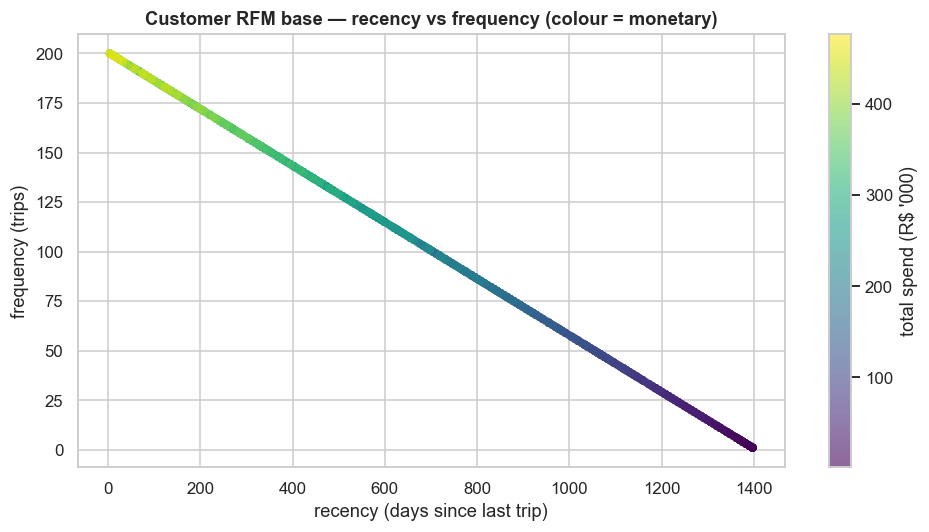

Median trips/user: 100 | median recency (days): 704


In [28]:
seg = udf.dropna(subset=["n_trips"])
plt.figure(figsize=(9, 5))
sc = plt.scatter(seg["recency_days"], seg["n_trips"], c=seg["total_spend"]/1e3,
                 cmap="viridis", alpha=0.6, s=20)
plt.colorbar(sc, label="total spend (R$ '000)")
plt.title("Customer RFM base — recency vs frequency (colour = monetary)")
plt.xlabel("recency (days since last trip)"); plt.ylabel("frequency (trips)")
savefig("15_rfm.png"); plt.show()
print("Median trips/user:", int(seg["n_trips"].median()),
      "| median recency (days):", int(seg["recency_days"].median()))

**Insight.** Frequency spans 1 to ~200 trips and recency 0–1395 days, giving clear high-value/at-risk
quadrants; monetary value tracks frequency, not demographics. **Business read —** these three axes
(R, F, M) are the ready-made feature base for a churn / segmentation model — the recommended next
analytical build after the three brief-specified models.

## 5. Solution to the Business Objective

**What the data tells us to build, and how.**

1. **Flight-price prediction (regression).** Price is a deterministic function of
   `(route, flightType, agency, distance)`. Build the regressor on those features, **drop `time`**
   (collinear with distance), and validate with **route/agency hold-outs** so the model proves it
   generalises instead of memorising the rate card. Comfortably clears the >75% bar → the effort goes
   into the **REST API, MLflow tracking, containerisation and drift monitoring**, i.e. the MLOps spine.

2. **Gender classification.** Train male-vs-female on the ~67% labelled users (well balanced) using
   behavioural + `company` features, then impute the **33% `none`** records to enrich personalisation.

3. **Hotel / travel recommendation.** Only **~30%** of trips include a hotel and demographics don't
   predict value — so recommend on **behaviour + route context** (home city, corridor, class, trip
   length). The ~70% hotel-less trips are the core revenue opportunity; push high-revenue properties on
   dense corridors.

4. **Platform priorities (PRD).** Since raw predictive difficulty is low, the capstone's value is the
   **productionization**: reproducible ingestion (Airflow), feature store, MLflow registry,
   FastAPI/Flask serving, and Evidently/Grafana monitoring — exactly the architecture in the system design.


## 6. Conclusion

**Data quality.** Three clean, fully-joinable tables (271,888 flight legs · 40,552 hotel stays ·
1,340 users) with **no missing values and no duplicates**. The only quirks are the `gender = none`
label (a modelling target, not an error) and 5 users with no flights.

**Structural findings.**
- Every `travelCode` is a **perfect round trip** (2 legs, A→B→A); hotel city and nights always match the
  flight, so each record set describes one coherent booking.
- Flight **price is a deterministic rate card** — fixed by route × class × agency, with `time` redundant
  to `distance`. No seasonality in fares.
- **`company` deterministically encodes home city**; demographics (age, gender, company) do **not** predict
  spend or frequency — value is behavioural.
- First class leads on both volume and revenue; **FlyingDrops is first-class-only**; hotel **attach rate
  is only ~30%**.

**Handoff.** Wrangled tables (`flights` leg-level, `trips` trip-level, `udf` user-level) and 15 saved
figures (`reports/figures/`) are the foundation for the modelling notebooks. The next phase implements the
three models above on top of these features, wrapped in the MLOps pipeline defined in the PRD and system
design.

---
*End of EDA — Voyage Analytics capstone.*
